In [10]:
import os
import glob
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import kagglehub
from greedy_algorithm.greedy import greedy_submodular_maximization, facility_location_score
from sklearn.impute import SimpleImputer  # Imported to handle missing values

In [3]:
print("Downloading dataset via kagglehub...")
download_path = kagglehub.dataset_download("rajyellow46/wine-quality")
print("Path to dataset files:", download_path)

# Find the CSV file inside the downloaded directory
csv_files = glob.glob(os.path.join(download_path, "*.csv"))
if not csv_files:
    raise FileNotFoundError("No CSV file found in the downloaded kagglehub directory.")

# Load the first available CSV file
df = pd.read_csv(csv_files[0])

# Drop the text column 'type' to keep only numerical features
if 'type' in df.columns:
    df = df.drop(columns=['type'])

# Separating features and target
X_raw = df.drop(columns=['quality'])
y = df['quality']

# --- DATA CLEANING: Handle missing values (NaN) ---
print(f"Checking for NaN values in features: {X_raw.isna().sum().sum()} missing values found.")

# SimpleImputer replaces all NaNs with the mean value of that specific column
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)

print("Missing values successfully imputed!")
print(f"Dataset loaded successfully. Total samples: {X.shape[0]}, Total features: {X.shape[1]}")

Path to dataset files: C:\Users\maria\.cache\kagglehub\datasets\rajyellow46\wine-quality\versions\1
Checking for NaN values in features: 38 missing values found.
Missing values successfully imputed!
Dataset loaded successfully. Total samples: 6497, Total features: 11


In [4]:

# Standard 80/20 stratified train-test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features (Crucial for RBF Kernel geometry!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

print(f"Full training pool size: {X_train_scaled.shape[0]}")
print(f"Testing pool size: {X_test_scaled.shape[0]}")

Full training pool size: 5197
Testing pool size: 1300


In [5]:
# Define how many core representative samples we want to select
k = 10

In [6]:
print("Training Baseline Model 1 (ALL training data)...")
rf_all = RandomForestClassifier(n_estimators=100, random_state=42)
t0 = time.time()
rf_all.fit(X_train_scaled, y_train_full)
t_all = time.time() - t0

preds_all = rf_all.predict(X_test_scaled)
acc_all = accuracy_score(y_test, preds_all)
f1_all = f1_score(y_test, preds_all, average='macro')

Training Baseline Model 1 (ALL training data)...


In [7]:
print(f"Training Baseline Model 2 ({k} RANDOM samples)...")
np.random.seed(42)

# Randomly pick k sample indices from the training pool
random_sample_indices = np.random.choice(X_train_scaled.shape[0], k, replace=False)

X_train_rand = X_train_scaled[random_sample_indices]
y_train_rand = y_train_full.iloc[random_sample_indices]

rf_rand = RandomForestClassifier(n_estimators=100, random_state=42)
t0 = time.time()
rf_rand.fit(X_train_rand, y_train_rand)
t_rand = time.time() - t0

preds_rand = rf_rand.predict(X_test_scaled)
acc_rand = accuracy_score(y_test, preds_rand)
f1_rand = f1_score(y_test, preds_rand, average='macro')

Training Baseline Model 2 (10 RANDOM samples)...


In [8]:
print("Calculating RBF Kernel Similarity Matrix between all training samples...")
similarity_matrix_samples = rbf_kernel(X_train_scaled, gamma=0.1)

print(f"Similarity matrix shape: {similarity_matrix_samples.shape}")

Calculating RBF Kernel Similarity Matrix between all training samples...
Similarity matrix shape: (5197, 5197)


In [11]:
print(f"Executing Greedy Submodular Maximization to find {k} core samples...")
t0 = time.time()

# Run the algorithm using your exact file signature
submodular_sample_indices = greedy_submodular_maximization(
    X_train_scaled.shape[0], k, similarity_matrix_samples
)
t_select = time.time() - t0

# Extract the chosen representative training data subset
X_train_sub = X_train_scaled[submodular_sample_indices]
y_train_sub = y_train_full.iloc[submodular_sample_indices]

Executing Greedy Submodular Maximization to find 10 core samples...
Starting selection of 10 elements out of 5197...
Step 1: Selected element 598, Marginal Gain: 2124.1963
Step 2: Selected element 659, Marginal Gain: 347.7676
Step 3: Selected element 1138, Marginal Gain: 270.2885
Step 4: Selected element 3764, Marginal Gain: 203.1106
Step 5: Selected element 853, Marginal Gain: 127.9908
Step 6: Selected element 1324, Marginal Gain: 76.2765
Step 7: Selected element 1561, Marginal Gain: 60.8154
Step 8: Selected element 57, Marginal Gain: 49.4010
Step 9: Selected element 2078, Marginal Gain: 40.5132
Step 10: Selected element 1498, Marginal Gain: 39.5580


In [12]:
print(f"Training Model 3 ({k} SUBMODULAR samples)...")
rf_sub = RandomForestClassifier(n_estimators=100, random_state=42)
t0 = time.time()
rf_sub.fit(X_train_sub, y_train_sub)
t_sub = time.time() - t0

preds_sub = rf_sub.predict(X_test_scaled)
acc_sub = accuracy_score(y_test, preds_sub)
f1_sub = f1_score(y_test, preds_sub, average='macro')

Training Model 3 (10 SUBMODULAR samples)...


Reconstructing the submodular function growth history from selected indices...
Simulating Random Selections for the submodular function baseline...


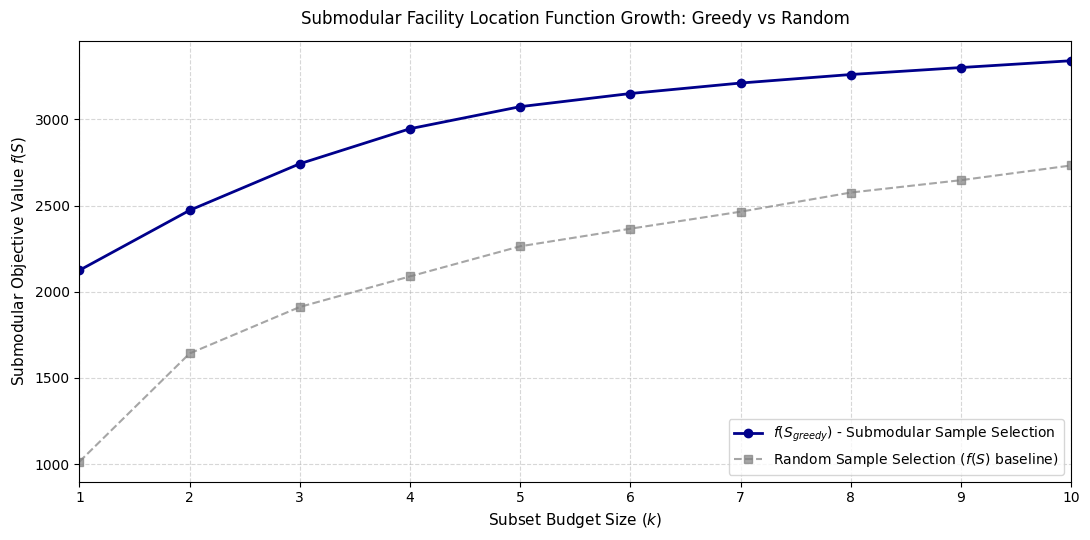

In [18]:
# %%
print("Reconstructing the submodular function growth history from selected indices...")
# Reconstruct the step-by-step scores using imported facility_location_score
history_sub = []
for step in range(1, k + 1):
    current_subset = submodular_sample_indices[:step]
    score = facility_location_score(current_subset, similarity_matrix_samples)
    history_sub.append(score)

print("Simulating Random Selections for the submodular function baseline...")
random_runs_f = []
all_indices = list(range(X_train_scaled.shape[0]))
for _ in range(20):
    np.random.shuffle(all_indices)
    run_history = []
    for step in range(1, k + 1):
        random_subset = all_indices[:step]
        score = facility_location_score(random_subset, similarity_matrix_samples)
        run_history.append(score)
    random_runs_f.append(run_history)
history_random_f = np.mean(random_runs_f, axis=0)

# Plotting the mathematical approximation guarantee visualization
plt.figure(figsize=(11, 5.5))
plt.plot(range(1, k + 1), history_sub, 'o-', color='darkblue', linewidth=2, label='$f(S_{greedy})$ - Submodular Sample Selection')
plt.plot(range(1, k + 1), history_random_f, 's--', color='gray', alpha=0.7, label='Random Sample Selection ($f(S)$ baseline)')

plt.title('Submodular Facility Location Function Growth: Greedy vs Random', fontsize=12, pad=12)
plt.xlabel('Subset Budget Size ($k$)', fontsize=11)
plt.ylabel('Submodular Objective Value $f(S)$', fontsize=11)
plt.xlim(1, k)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

In [14]:
print("\n" + "="*60)
print("FINAL BENCHMARK RESULTS (WINE QUALITY DATA SUBSET SELECTION):")
print("="*60)
print(f"1. FULL DATASET TRAINING Pool ({X_train_full.shape[0]} samples):")
print(f"   Accuracy: {acc_all:.4f} | F1-Score (Macro): {f1_all:.4f} | Training Time: {t_all:.4f}s")

print(f"\n2. RANDOM SUBSET TRAINING ({k} samples):")
print(f"   Accuracy: {acc_rand:.4f} | F1-Score (Macro): {f1_rand:.4f} | Training Time: {t_rand:.4f}s")

print(f"\n3. SUBMODULAR CORESET TRAINING ({k} samples):")
print(f"   Accuracy: {acc_sub:.4f} | F1-Score (Macro): {f1_sub:.4f} | Training Time: {t_sub:.4f}s")
print(f"   (Data Selection Execution Time: {t_select:.4f}s)")
print("="*60)


FINAL BENCHMARK RESULTS (WINE QUALITY DATA SUBSET SELECTION):
1. FULL DATASET TRAINING Pool (5197 samples):
   Accuracy: 0.6738 | F1-Score (Macro): 0.3839 | Training Time: 1.2501s

2. RANDOM SUBSET TRAINING (10 samples):
   Accuracy: 0.2731 | F1-Score (Macro): 0.1321 | Training Time: 0.1990s

3. SUBMODULAR CORESET TRAINING (10 samples):
   Accuracy: 0.4392 | F1-Score (Macro): 0.1623 | Training Time: 0.1255s
   (Data Selection Execution Time: 20.7930s)


Starting Budget Scaling Experiment...
Evaluating budget k = 10...
Evaluating budget k = 20...
Starting selection of 20 elements out of 5197...
Step 1: Selected element 598, Marginal Gain: 2124.1963
Step 2: Selected element 659, Marginal Gain: 347.7676
Step 3: Selected element 1138, Marginal Gain: 270.2885
Step 4: Selected element 3764, Marginal Gain: 203.1106
Step 5: Selected element 853, Marginal Gain: 127.9908
Step 6: Selected element 1324, Marginal Gain: 76.2765
Step 7: Selected element 1561, Marginal Gain: 60.8154
Step 8: Selected element 57, Marginal Gain: 49.4010
Step 9: Selected element 2078, Marginal Gain: 40.5132
Step 10: Selected element 1498, Marginal Gain: 39.5580
Step 11: Selected element 2441, Marginal Gain: 38.3059
Step 12: Selected element 2502, Marginal Gain: 35.2153
Step 13: Selected element 1255, Marginal Gain: 31.1462
Step 14: Selected element 573, Marginal Gain: 28.3577
Step 15: Selected element 1437, Marginal Gain: 28.1110
Step 16: Selected element 2692, Marginal 

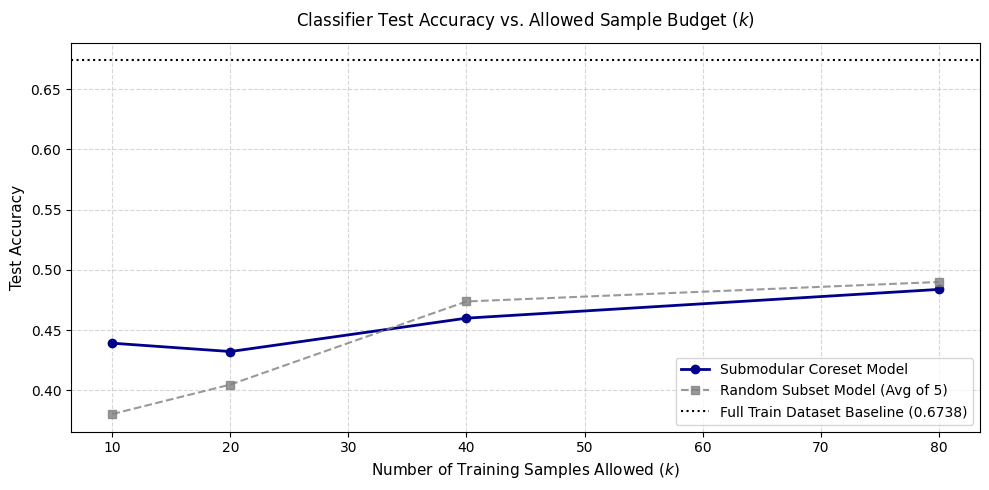

In [16]:
print("Starting Budget Scaling Experiment...")
budgets = [10, 20, 40, 80]

greedy_accs = []
random_accs = []

# Averaging the random baseline over 5 independent runs per budget for statistical stability
n_random_runs = 5 

for b in budgets:
    print(f"Evaluating budget k = {b}...")
    
    # 1. Submodular Coreset Generation for current budget
    # If the budget is smaller or equal to our main experiment, we can reuse indices. 
    # Otherwise, we execute the greedy selection for the larger budget size.
    if b <= len(submodular_sample_indices):
        sub_indices = submodular_sample_indices[:b]
    else:
        sub_indices = greedy_submodular_maximization(X_train_scaled.shape[0], b, similarity_matrix_samples)
    
    rf_g = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_g.fit(X_train_scaled[sub_indices], y_train_full.iloc[sub_indices])
    greedy_accs.append(accuracy_score(y_test, rf_g.predict(X_test_scaled)))
    
    # 2. Averaged Random Subset Generation for current budget
    current_budget_rand_accs = []
    for run in range(n_random_runs):
        np.random.seed(42 + run)
        rand_indices = np.random.choice(X_train_scaled.shape[0], b, replace=False)
        
        rf_r = RandomForestClassifier(n_estimators=100, random_state=42)
        rf_r.fit(X_train_scaled[rand_indices], y_train_full.iloc[rand_indices])
        current_budget_rand_accs.append(accuracy_score(y_test, rf_r.predict(X_test_scaled)))
        
    random_accs.append(np.mean(current_budget_rand_accs))

# Plotting the Data Efficiency Learning Curves
plt.figure(figsize=(10, 5))
plt.plot(budgets, greedy_accs, 'o-', color='darkblue', linewidth=2, label='Submodular Coreset Model')
plt.plot(budgets, random_accs, 's--', color='gray', alpha=0.8, label=f'Random Subset Model (Avg of {n_random_runs})')
plt.axhline(y=acc_all, color='black', linestyle=':', label=f'Full Train Dataset Baseline ({acc_all:.4f})')

plt.title('Classifier Test Accuracy vs. Allowed Sample Budget ($k$)', fontsize=12, pad=12)
plt.xlabel('Number of Training Samples Allowed ($k$)', fontsize=11)
plt.ylabel('Test Accuracy', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import GridSearchCV

print("Configuring Hyperparameter Tuning for Selected Data Subsets...")
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

# 1. Grid Search on the Submodular Coreset
print("Running Grid Search on Submodular Coreset samples...")
grid_sub = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring="accuracy", n_jobs=-1)
grid_sub.fit(X_train_sub, y_train_sub)
best_tuned_sub_acc = accuracy_score(y_test, grid_sub.best_estimator_.predict(X_test_scaled))

# 2. Grid Search on the Random Subset
print("Running Grid Search on Random Subset samples...")
grid_rand = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring="accuracy", n_jobs=-1)
grid_rand.fit(X_train_rand, y_train_rand)
best_tuned_rand_acc = accuracy_score(y_test, grid_rand.best_estimator_.predict(X_test_scaled))

print("\n" + "="*60)
print("GRID SEARCH HYPERPARAMETER TUNING RESULTS:")
print("="*60)
print(f"Best Submodular Model Hyperparameters: {grid_sub.best_params_}")
print(f"Tuned Submodular Coreset Test Accuracy: {best_tuned_sub_acc:.4f}")
print(f"Tuned Random Subset Test Accuracy:     {best_tuned_rand_acc:.4f}")
print("="*60)

Configuring Hyperparameter Tuning for Selected Data Subsets...
Running Grid Search on Submodular Coreset samples...


C:\Users\maria\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Running Grid Search on Random Subset samples...


C:\Users\maria\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(



GRID SEARCH HYPERPARAMETER TUNING RESULTS:
Best Submodular Model Hyperparameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Tuned Submodular Coreset Test Accuracy: 0.4408
Tuned Random Subset Test Accuracy:     0.2862
